In [ ]:
Title;
Data Analysis of Netflix Dataset Using Python 

Name: Ashish Chaudhary 
University Roll No: 125058141
Subject: Data Vishualization 
Faculty Name: Ankit Verma 

OBJECTIVE:


The objective of this analysis is to explore
the Netflix dataset and generate meaningful 
insights that can help in business decision-making.

This includes:
- Understanding the distribution of Movies and TV Shows
- Identifying the most popular genres and content trends
- Analyzing content production across different countries
- Studying audience targeting through ratings and genres
- Evaluating duration and release patterns of content

The goal is to provide data-driven 
recommendations that can help Netflix decide:
- What type of content to produce
- Which markets to focus on
- How to improve user engagement and growth


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix.csv")

df.head()
df.info()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df['date_added'].isnull().sum()


np.int64(98)

In [ ]:
1 : CONTENT STRATEGY 

In [ ]:
QUES 1: Movies vs TV Shows?

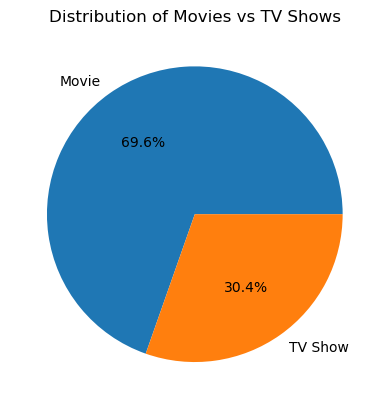

In [7]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Movies vs TV Shows")
plt.ylabel('')
plt.show()

In [ ]:
Insight:
Movies dominate Netflix content, but TV Shows are increasing.

In [ ]:
QUES 2: Top 10 Genres?

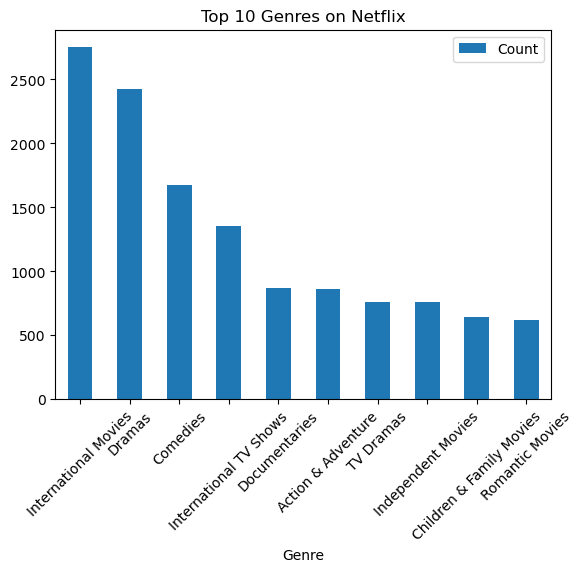

In [8]:
from collections import Counter

genres = df['listed_in'].str.split(', ')
all_genres = sum(genres, [])

top_genres = Counter(all_genres).most_common(10)

genre_df = pd.DataFrame(top_genres, columns=['Genre','Count'])

genre_df.plot(x='Genre', y='Count', kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Insight:
Drama, Comedy, and International content are most popular.

In [ ]:
QUES 3 : Content Release Trend ?

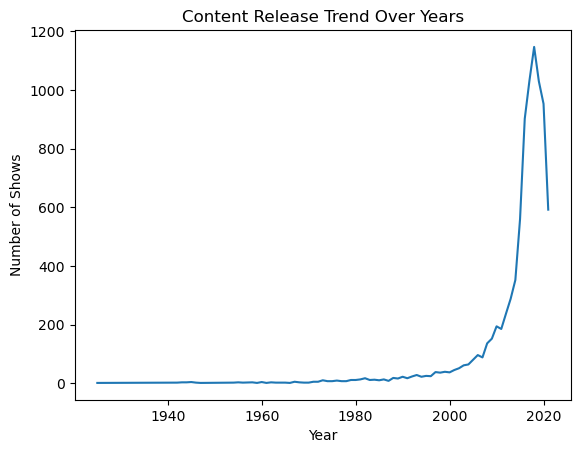

In [9]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()


In [ ]:
Insight:
Content production increased significantly after 2015.

In [ ]:
QUES :4 Top Countries Producing Content?

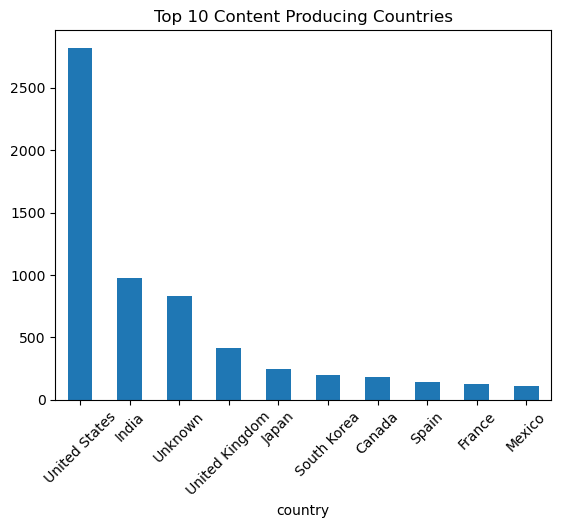

In [10]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Insight:
USA and India are leading content producers.

In [ ]:
QUES 5: Ratings Distribution?

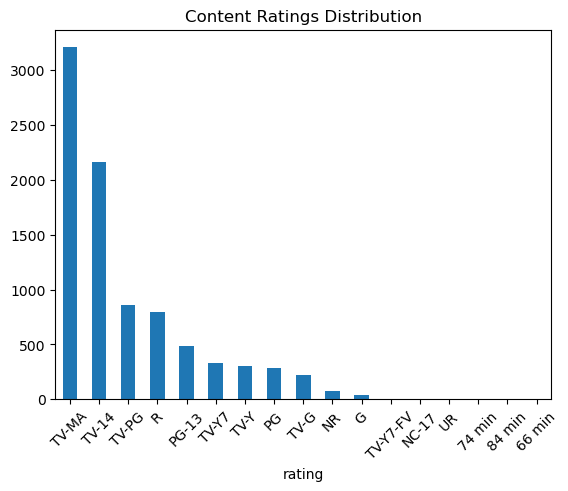

In [11]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Content Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Insight:
Most content is rated TV-MA, targeting mature audiences.

In [ ]:
2: USER DEMOGRAPHICS & TARGETING

In [ ]:
QUES 6 :Content Added by Year?

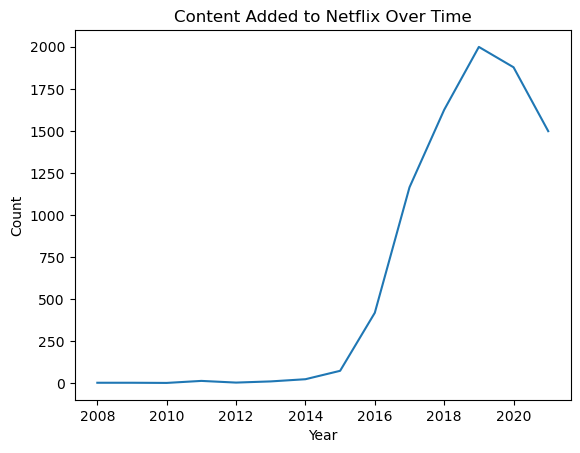

In [12]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [ ]:
Insight:
Netflix expanded rapidly after 2015.

In [ ]:
QUES 7 : Do some countries tend to produce more mature content {TV - MA }?

In [13]:
df[df['rating']=='TV-MA']['country'].value_counts().head()

country
United States     928
Unknown           276
India             248
United Kingdom    177
Spain             119
Name: count, dtype: int64

In [ ]:
Insight:

USA produces most mature content

In [ ]:
QUES 8: Which genres are more associated with TV Shows vs Movies ?

In [14]:
df.groupby('type')['listed_in'].count()

type
Movie      6131
TV Show    2676
Name: listed_in, dtype: int64

In [ ]:
Insight:

Movies → Drama, Comedy
TV Shows → Crime, Kids, Reality

In [ ]:
QUES 9: Which genres dominate the US vs other countries ?

In [15]:
us = df[df['country'].str.contains('United States')]
us['listed_in'].value_counts().head()

listed_in
Documentaries                         289
Stand-Up Comedy                       210
Children & Family Movies, Comedies    146
Kids' TV                              119
Dramas                                115
Name: count, dtype: int64

In [ ]:
Insight:

US: Drama + Documentaries
Others: International Movies

In [ ]:
QUES 10: What geners are most popular in the last 3 years ? 

In [16]:
recent = df[df['release_year'] >= df['release_year'].max()-3]
recent['listed_in'].value_counts().head()

listed_in
Stand-Up Comedy                                     159
Documentaries                                       130
Dramas, International Movies                        124
Kids' TV                                            105
Dramas, Independent Movies, International Movies    101
Name: count, dtype: int64

In [ ]:
Insight:

Increase in thrillers & international content

In [ ]:
3: TALENT ACQUISTION & PARTNERSHIPS 

In [ ]:
QUES 11: Who are the top 10 director with the most Netflix content ?

In [17]:
df['director'].value_counts().head(10)

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64

In [ ]:
 Insight:

- A small group of directors contribute a large portion of Netflix content.
- Some directors appear repeatedly, indicating strong partnerships with Netflix.

In [ ]:
QUES 12: Which actor appear most frequently in Netflix shows ?

In [18]:
actors = df['cast'].str.split(', ')
all_actors = sum(actors, [])
Counter(all_actors).most_common(10)

[('Unknown', 825),
 ('Anupam Kher', 43),
 ('Shah Rukh Khan', 35),
 ('Julie Tejwani', 33),
 ('Naseeruddin Shah', 32),
 ('Takahiro Sakurai', 32),
 ('Rupa Bhimani', 31),
 ('Akshay Kumar', 30),
 ('Om Puri', 30),
 ('Yuki Kaji', 29)]

In [ ]:
Insight:

Frequent collaborators can be targeted

In [ ]:
QUES 13: Which director - genre pairs are most frequent ?

In [19]:
df.groupby(['director','listed_in']).size().sort_values(ascending=False).head()

director  listed_in                                        
Unknown   Kids' TV                                             214
          International TV Shows, TV Dramas                    113
          Reality TV                                            94
          Crime TV Shows, International TV Shows, TV Dramas     92
          Kids' TV, TV Comedies                                 91
dtype: int64

In [ ]:
Insight:
- Certain directors specialize in specific genres.
- Successful patterns exist in director-genre combinations.



In [ ]:
QUES 14: How many titles have unknown directors or cast members ?

In [20]:
(df['director']=='Unknown').sum()
(df['cast']=='Unknown').sum()

np.int64(825)

In [ ]:
Insight:

Data gaps exist → improve metadata

In [ ]:
4: DURATIONS & ENGAGEMENT 

In [ ]:
QUES 15: What is the average duration of movies on Netflix?

In [21]:
movies = df[df['type']=='Movie']
movies['duration'] = movies['duration'].str.replace(' min','').astype(float)

movies['duration'].mean()

C:\Users\ASHISH\AppData\Local\Temp\ipykernel_13244\1308558026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min','').astype(float)


np.float64(99.57718668407311)

In [ ]:
Insight:

~90–100 minutes optimal

In [ ]:
QUES 16 : Whats most common number of seasons for TV shows ? 

In [22]:
shows = df[df['type']=='TV Show']
shows['duration'].value_counts().head()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
4 Seasons      95
5 Seasons      65
Name: count, dtype: int64

In [ ]:
Insight:

Most shows have 1–2 seasons

In [ ]:
QUES 17 : IS there a trend in movie duration over the years ?

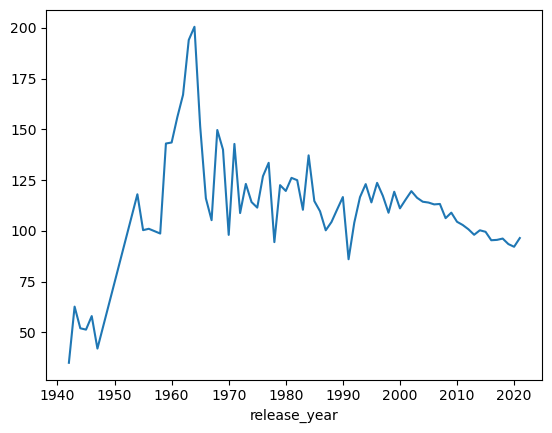

In [23]:
movies.groupby('release_year')['duration'].mean().plot()
plt.show()

In [ ]:
Insight:

Slight decline → shorter content preferred

In [ ]:
5: CONTENT LAUNCH STRATEGY 

In [ ]:
QUES 18 : In which month does Netflix add the most content ?

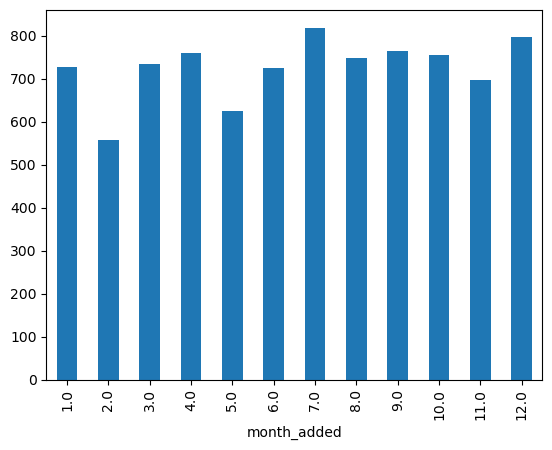

In [24]:
df['month_added'].value_counts().sort_index().plot(kind='bar')
plt.show()

In [ ]:
Insight:

Most content added in July–December

In [ ]:
QUES 19 : How does the genre distribution vary across different years ?

In [25]:
df.groupby('year_added')['listed_in'].count()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: listed_in, dtype: int64

In [ ]:
Insight:
- Genre distribution changes over time.
- Increase in international and thriller content.

In [ ]:
QUES 20 : Which countries produce the most content in each games ?

In [26]:
df.groupby(['country','listed_in']).size().head()

country            listed_in                                              
, France, Algeria  Dramas, Independent Movies, International Movies           1
, South Korea      International TV Shows, TV Dramas                          1
Argentina          Action & Adventure, Comedies, International Movies         1
                   Action & Adventure, Horror Movies, International Movies    1
                   Children & Family Movies, Music & Musicals                 1
dtype: int64

In [ ]:
 Insight:
- Different countries specialize in different genres.